# MSFT Next-Day Direction Predictor — Iteration 4

**Author:** Lucan den Dekker  
**Project:** ADSAI Group 15 Block D Capstone  
**Date:** 2026-05-30  

---

---

## Improvements over Iteration 3

| Change | Reason |
|---|---|
| **Only last 2 years of data** (2024–2026) | Older data reflects different market regimes; more distant history adds noise rather than signal in a high-volatility environment |
| **NYSE holiday calendar alignment** | Data fetched via yfinance already skips closed days; we additionally compute trading-day gaps to detect holiday-adjacent sessions |
| **Holiday proximity features** | Pre- and post-holiday sessions show statistically different return distributions (thin volume, gap-opens) |
| **LSTM with 30-day lookback** | Captures 6 weeks of sequential market memory; classical ML treats every day as independent and cannot represent "3 consecutive down days followed by a reversal" |
| **Amazon Chronos Bolt pretrained model** | Zero-shot time-series forecasting; pre-trained on billions of real-world time series — no fine-tuning required, applied directly to MSFT close prices |
| **Data fetched fresh via yfinance** | Always uses current data; avoids stale local CSVs |

---

## Why it1–it3 stayed at baseline

Logistic Regression, Random Forest, and XGBoost all treat each trading day as an **independent observation** — they receive a flat feature vector for day *t* and produce a prediction. They have no built-in concept of "what happened yesterday, or five days ago, shapes what happens today." LSTM processes ordered **sequences** and can learn temporal patterns across 30 consecutive trading days, making it a fundamentally better fit for financial time series.

| Section | Content |
|---|---|
| 0 | Imports and Setup |
| 1 | Data Collection (yfinance, last 2 years) |
| 2 | Data Cleaning — NYSE Holiday Alignment |
| 3 | Feature Engineering |
| 4 | Sequence Creation (30-day LSTM windows) |
| 5 | Baseline Model |
| 6 | LSTM Model (PyTorch) |
| 7 | Amazon Chronos Bolt (Pretrained) |
| 8 | Model Comparison |
| 9 | Error Analysis |
| 10 | Business Value Interpretation |

In [18]:
%pip install pandas numpy matplotlib seaborn scikit-learn yfinance torch joblib
%pip install chronos-forecasting

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


---
## Section 0 — Imports and Setup

`RANDOM_SEED = 42` propagates through numpy, PyTorch, and Python's own `random` to ensure full
reproducibility. `RobustScaler` is preferred for financial returns because extreme outliers
(e.g. pandemic crashes) would distort `StandardScaler`'s mean/std estimates.

In [19]:
import warnings
import logging
import random
from pathlib import Path
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import yfinance as yf

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from xgboost import XGBClassifier

import joblib

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_SEED: int = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
warnings.filterwarnings("ignore")

# ── Logging ───────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("msft_it4")

# ── Plot style ────────────────────────────────────────────────────────────────
try:
    plt.style.use("seaborn-v0_8-darkgrid")
except OSError:
    plt.style.use("seaborn-darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13

# ── Project paths ─────────────────────────────────────────────────────────────
def find_project_root(marker: str = "README.md") -> Path:
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    logger.warning("Project root not found; falling back to cwd.")
    return current


PROJECT_ROOT = find_project_root()
MODEL_DIR = PROJECT_ROOT / "models" / "lucan"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
logger.info("Project root: %s", PROJECT_ROOT)
logger.info("Model directory: %s", MODEL_DIR)

ModuleNotFoundError: No module named 'xgboost'

---
## Section 1 — Data Collection

Data is fetched fresh via **yfinance** for the last 2 years. This keeps the model trained
on the most relevant recent market regime.

Tickers used:
| Ticker | Meaning | Column |
|---|---|---|
| `MSFT` | Microsoft stock | `msft_close`, `msft_high`, `msft_low`, `msft_volume` |
| `SPY` | S&P 500 ETF (`spy_close`) | `spy_close` — broad market direction proxy |
| `GLD` | Gold ETF | `gld_close` |
| `USO` | Oil ETF | `uso_close` |
| `^VIX` | CBOE Volatility Index | `vix_close` — market fear gauge |

**Why only 2 years?** Elavendan's recommendation: the farther back you go, the more the market
structure differs from today. Using 10 years of data forces the model to learn patterns from
a pre-pandemic, pre-AI-bubble era that are no longer predictive.

In [ ]:
# ── Date range: last 4 years from today ──────────────────────────────────────
# 2 years gave only ~312 training sequences — too few for LSTM to learn.
# 4 years (~800 sequences) gives the model enough history without going back
# to pre-pandemic market regimes that are fully irrelevant.
END_DATE: str = date.today().strftime("%Y-%m-%d")
START_DATE: str = (date.today() - timedelta(days=4 * 365 + 30)).strftime("%Y-%m-%d")
logger.info("Fetching data: %s → %s", START_DATE, END_DATE)

# ── Download each ticker individually ────────────────────────────────────────
_ticker_map = {
    "MSFT": "msft",
    "SPY": "spy",
    "GLD": "gld",
    "USO": "uso",
    "^VIX": "vix",
}

raw_series: dict = {}
raw_ohlcv: dict = {}

for ticker, name in _ticker_map.items():
    _df = yf.download(
        ticker,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=True,
        progress=False,
    )
    # yfinance ≥0.2 returns MultiIndex columns when group_by='column'
    if isinstance(_df.columns, pd.MultiIndex):
        _df.columns = _df.columns.get_level_values(0)
    _df.index = pd.to_datetime(_df.index).normalize()
    raw_series[f"{name}_close"] = _df["Close"]
    if "Volume" in _df.columns:
        raw_series[f"{name}_volume"] = _df["Volume"]
    if name == "msft":
        raw_ohlcv["msft_open"] = _df["Open"]
        raw_ohlcv["msft_high"] = _df["High"]
        raw_ohlcv["msft_low"] = _df["Low"]
    logger.info("  %s (%s): %d rows", ticker, name, len(_df))

# ── Merge into a single DataFrame on trading-day index ───────────────────────
df_raw = pd.concat(list(raw_series.values()) + list(raw_ohlcv.values()), axis=1)
df_raw.columns = list(raw_series.keys()) + list(raw_ohlcv.keys())
df_raw.index.name = "Date"
df_raw.sort_index(inplace=True)

# Drop rows where MSFT itself has no close price
df_raw = df_raw.dropna(subset=["msft_close"])

logger.info("Merged raw dataset: shape=%s | %s → %s",
            df_raw.shape, df_raw.index.min().date(), df_raw.index.max().date())
print(df_raw.tail())

2026-05-30 14:34:52 | INFO | Fetching data: 2022-05-01 → 2026-05-30
2026-05-30 14:34:54 | INFO |   MSFT (msft): 1023 rows
2026-05-30 14:34:55 | INFO |   SPY (spy): 1023 rows
2026-05-30 14:34:55 | INFO |   GLD (gld): 1023 rows
2026-05-30 14:34:55 | INFO |   USO (uso): 1023 rows
2026-05-30 14:34:56 | INFO |   ^VIX (vix): 1024 rows
2026-05-30 14:34:56 | INFO | Merged raw dataset: shape=(1023, 13) | 2022-05-02 → 2026-05-29


            msft_close  msft_volume   spy_close  spy_volume   gld_close  \
Date                                                                      
2026-05-22  418.570007   22390300.0  745.640015  41762000.0  413.820007   
2026-05-26  416.029999   30398000.0  750.590027  41123600.0  414.000000   
2026-05-27  412.670013   28901500.0  750.460022  42106300.0  408.489990   
2026-05-28  426.989990   47250500.0  754.599976  41562600.0  412.769989   
2026-05-29  450.239990   79522600.0  756.479980  54976100.0  417.119995   

            gld_volume   uso_close  uso_volume  vix_close  vix_volume  \
Date                                                                    
2026-05-22   5528400.0  140.919998   7541300.0  16.700001           0   
2026-05-26   5098400.0  137.000000   7574200.0  17.010000           0   
2026-05-27   6624600.0  131.029999   8423300.0  16.290001           0   
2026-05-28   7184100.0  130.779999   7533300.0  15.740000           0   
2026-05-29   7681100.0  129.089996  

---
## Section 2 — Data Cleaning: NYSE Holiday Alignment

yfinance only returns rows for actual trading days, so the index is already holiday-free.
What we still need to do:

1. **Forward-fill macro/ETF gaps** — GLD/USO/VIX sometimes have data on days when MSFT does
   not, and vice versa. After the inner join we forward-fill at most 1 day for lagged series.
2. **Detect holiday-adjacent sessions** — by examining the calendar gap to the previous and
   next trading day. A gap `> 3` calendar days means a US holiday extended the weekend.
   A gap `== 2` on a non-Monday/Friday means a mid-week holiday (e.g. Thanksgiving).
3. **Add US-calendar time features** — day-of-week, month, and a December/January seasonality
   flag (tax-loss harvesting, Santa Claus rally).

**Why align with the US calendar?** The stock market is US-centred; MSFT, SPY, GLD and USO
all follow NYSE/NASDAQ trading hours. Non-US holidays (e.g. UK bank holidays) do not create
gaps here.

In [ ]:
df = df_raw.copy()

# ── Forward-fill commodity/VIX for at most 1 business day ────────────────────
# (handles rare single-day data holes without introducing lookahead)
for col in ["spy_close", "gld_close", "uso_close", "vix_close"]:
    if col in df.columns:
        df[col] = df[col].ffill(limit=1)

# Drop rows still missing after fill (start-of-window edges)
df = df.dropna(subset=["msft_close", "spy_close", "gld_close", "uso_close", "vix_close"])

# ── Trading-day gap features ─────────────────────────────────────────────────
dates = df.index

# Calendar days elapsed since the previous trading session
gap_before = pd.Series(
    [(dates[i] - dates[i - 1]).days if i > 0 else 1 for i in range(len(dates))],
    index=dates,
    name="gap_before",
)

# Calendar days until the next trading session
gap_after = pd.Series(
    [(dates[i + 1] - dates[i]).days if i < len(dates) - 1 else 1 for i in range(len(dates))],
    index=dates,
    name="gap_after",
)

df["gap_before"] = gap_before
df["gap_after"] = gap_after

# Post-holiday session: arrived after a gap longer than a normal 3-day weekend
# gap_before > 3  => e.g. Friday→Tuesday when Monday is a holiday (4 days)
# gap_before == 2 AND not Monday => mid-week holiday (e.g. Wednesday Thanksgiving-day-after)
df["is_post_holiday"] = (
    (df["gap_before"] > 3)
    | ((df["gap_before"] == 2) & (df.index.dayofweek != 0))
).astype(int)

# Pre-holiday session: next trading day is further away than usual
df["is_pre_holiday"] = (
    (df["gap_after"] > 3)
    | ((df["gap_after"] == 2) & (df.index.dayofweek != 4))
).astype(int)

# ── Calendar / seasonality features ─────────────────────────────────────────
df["day_of_week"] = df.index.dayofweek          # 0=Mon … 4=Fri
df["is_monday"] = (df.index.dayofweek == 0).astype(int)
df["is_friday"] = (df.index.dayofweek == 4).astype(int)
df["month"] = df.index.month
df["is_december"] = (df.index.month == 12).astype(int)   # Santa Claus rally / year-end
df["is_january"] = (df.index.month == 1).astype(int)     # Tax-loss harvesting rebound

logger.info(
    "After cleaning: %d rows | post-holiday: %d | pre-holiday: %d",
    len(df), df["is_post_holiday"].sum(), df["is_pre_holiday"].sum(),
)
print(df[["msft_close", "spy_close", "vix_close", "gap_before", "is_post_holiday"]].tail(10))

2026-05-30 14:34:56 | INFO | After cleaning: 1023 rows | post-holiday: 42 | pre-holiday: 42


            msft_close   spy_close  vix_close  gap_before  is_post_holiday
Date                                                                      
2026-05-15  421.008148  739.169983  18.430000           1                0
2026-05-18  422.624664  738.650024  17.820000           3                0
2026-05-19  416.517883  733.729980  18.059999           1                0
2026-05-20  420.149994  741.250000  17.440001           1                0
2026-05-21  419.089996  742.719971  16.760000           1                0
2026-05-22  418.570007  745.640015  16.700001           1                0
2026-05-26  416.029999  750.590027  17.010000           4                1
2026-05-27  412.670013  750.460022  16.290001           1                0
2026-05-28  426.989990  754.599976  15.740000           1                0
2026-05-29  450.239990  756.479980  15.320000           1                0


---
## Section 3 — Feature Engineering

All features are **scale-invariant** (percentage changes, ratios, oscillators) to prevent
absolute price levels from dominating the LSTM gradients.

**Target** — same definition as it2/it3:  
`next_day_return > +0.2 %` → UP (1)  
`next_day_return < −0.2 %` → DOWN (0)  
Neutral rows (|return| ≤ 0.2 %) are **discarded**.

| Feature | Type | Description |
|---|---|---|
| `daily_return` | MSFT momentum | Today's close-to-close return % |
| `price_range_pct` | MSFT volatility | (High−Low)/Close intraday range |
| `rsi_14` | Momentum oscillator | Overbought/oversold 0–100 |
| `momentum_5` | Short-term trend | 5-day cumulative return % |
| `momentum_10` | Medium-term trend | 10-day cumulative return % |
| `close_to_sma5_pct` | Trend deviation | Distance from 5-day MA |
| `close_to_sma20_pct` | Trend deviation | Distance from 20-day MA |
| `sma_crossover` | Trend signal | SMA5 / SMA20 — golden/death cross |
| `rolling_std_5` | Volatility | 5-day rolling std of returns |
| `volume_ratio` | Volume signal | Today's volume / 20-day avg |
| `lag_spy_return` | Market proxy | Yesterday's SPY return (spy_close) |
| `spy_rsi_14` | Market oscillator | SPY RSI — broad market overbought/oversold |
| `lag_gold_return` | Macro | Yesterday's GLD return |
| `lag_oil_return` | Macro | Yesterday's USO return |
| `lag_vix_1` | Fear gauge | Yesterday's VIX level |
| `vix_change` | Fear delta | VIX % change today |
| `gap_before` | Calendar | Calendar days since last trade |
| `is_post_holiday` | Calendar | Came after US holiday closure |
| `is_pre_holiday` | Calendar | Day before US holiday closure |
| `is_monday` | Calendar | Monday seasonality |
| `is_friday` | Calendar | Friday seasonality |
| `is_december` | Seasonality | Year-end effects |
| `is_january` | Seasonality | Tax-loss harvesting rebound |

In [ ]:
NEUTRAL_THRESHOLD: float = 0.2


def _rsi(series: pd.Series, window: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=window - 1, min_periods=window).mean()
    avg_loss = loss.ewm(com=window - 1, min_periods=window).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return (100 - 100 / (1 + rs)).fillna(50)


def _macd(close: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    return macd_line, signal_line, macd_line - signal_line


def engineer_features(df: pd.DataFrame, threshold: float = NEUTRAL_THRESHOLD) -> pd.DataFrame:
    out = df.copy()
    close = out["msft_close"]

    # Target
    next_ret = close.pct_change().shift(-1) * 100
    out["target"] = np.where(
        next_ret > threshold, 1,
        np.where(next_ret < -threshold, 0, np.nan),
    )

    # MSFT technical
    ret = close.pct_change() * 100
    out["daily_return"]       = ret
    out["price_range_pct"]    = (out["msft_high"] - out["msft_low"]) / close * 100
    out["overnight_gap"]      = (out["msft_open"] - close.shift(1)) / close.shift(1) * 100
    out["rsi_14"]             = _rsi(close)
    out["momentum_5"]         = close.pct_change(5) * 100
    out["momentum_10"]        = close.pct_change(10) * 100
    out["close_to_sma5_pct"]  = (close / close.rolling(5).mean() - 1) * 100
    out["close_to_sma20_pct"] = (close / close.rolling(20).mean() - 1) * 100
    out["sma_crossover"]      = close.rolling(5).mean() / close.rolling(20).mean()
    out["rolling_std_5"]      = ret.rolling(5).std()
    out["rolling_std_20"]     = ret.rolling(20).std()
    out["vol_ratio"]          = out["rolling_std_5"] / out["rolling_std_20"].replace(0, np.nan)

    # MACD — most consistently cited predictor in stock direction literature
    out["macd_line"], out["macd_signal"], out["macd_hist"] = _macd(close)

    # Volume
    if "msft_volume" in out.columns:
        out["volume_ratio"] = out["msft_volume"] / out["msft_volume"].rolling(20).mean()
    else:
        out["volume_ratio"] = 1.0

    # SPY (spy_close = S&P 500 ETF closing price — broad market proxy)
    spy_ret = out["spy_close"].pct_change() * 100
    out["lag_spy_return"] = spy_ret.shift(1)
    out["spy_rsi_14"]     = _rsi(out["spy_close"])

    # Macro
    out["lag_gold_return"] = out["gld_close"].pct_change().shift(1) * 100
    out["lag_oil_return"]  = out["uso_close"].pct_change().shift(1) * 100
    out["lag_vix_1"]       = out["vix_close"].shift(1)
    out["vix_change"]      = out["vix_close"].pct_change() * 100

    return out


df_feat = engineer_features(df)
df_feat = df_feat.dropna()
df_feat["target"] = df_feat["target"].astype(int)

logger.info("After feature engineering: %d rows", len(df_feat))
print(f"Class distribution:\n{df_feat['target'].value_counts()}")
print(f"UP fraction: {df_feat['target'].mean():.2%}")

---
## Section 4 — Sequence Creation for LSTM

An LSTM needs input in the shape `(samples, timesteps, features)`.

- `LOOKBACK = 30` trading days ≈ 6 calendar weeks of market memory.
- Each sample is a 30-day window of scaled features; the label is the direction on day 31.
- The **train/test split is time-ordered** (no shuffle) to prevent data leakage: the model
  is trained on the past and evaluated on the future, exactly as in production.

In [ ]:
LOOKBACK: int = 30

FEATURE_COLS: list = [
    # MSFT price action
    "daily_return", "price_range_pct", "overnight_gap",
    # Momentum & trend
    "rsi_14", "momentum_5", "momentum_10",
    "close_to_sma5_pct", "close_to_sma20_pct", "sma_crossover",
    # MACD (most cited predictor in literature)
    "macd_line", "macd_signal", "macd_hist",
    # Volatility
    "rolling_std_5", "rolling_std_20", "vol_ratio",
    # Volume
    "volume_ratio",
    # Market / macro
    "lag_spy_return", "spy_rsi_14",
    "lag_gold_return", "lag_oil_return",
    "lag_vix_1", "vix_change",
    # Calendar
    "gap_before", "is_post_holiday", "is_pre_holiday",
    "is_monday", "is_friday", "is_december", "is_january",
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_feat.columns]
N_FEATURES: int = len(FEATURE_COLS)
logger.info("Using %d features", N_FEATURES)

X_raw = df_feat[FEATURE_COLS].values.astype(np.float32)
y_raw = df_feat["target"].values.astype(np.float32)

# ── Scale: fit only on train rows to avoid look-ahead ────────────────────────
SPLIT_RATIO: float = 0.8
split_flat = int(len(X_raw) * SPLIT_RATIO)

scaler = RobustScaler()
X_scaled = X_raw.copy()
X_scaled[:split_flat] = scaler.fit_transform(X_raw[:split_flat])
X_scaled[split_flat:] = scaler.transform(X_raw[split_flat:])

# Also keep flat (unsequenced) arrays for XGBoost
X_flat_train = X_scaled[:split_flat]
y_flat_train = y_raw[:split_flat]
X_flat_test  = X_scaled[split_flat:]
y_flat_test  = y_raw[split_flat:]

# ── Create 30-day sequences for LSTM ─────────────────────────────────────────
def create_sequences(X: np.ndarray, y: np.ndarray, lookback: int = 30):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback : i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


X_seq, y_seq = create_sequences(X_scaled, y_raw, lookback=LOOKBACK)
logger.info("Sequences: X=%s  y=%s", X_seq.shape, y_seq.shape)

split_seq = int(len(X_seq) * SPLIT_RATIO)
X_train, X_test = X_seq[:split_seq], X_seq[split_seq:]
y_train, y_test = y_seq[:split_seq], y_seq[split_seq:]

test_dates = df_feat.index[LOOKBACK + split_seq:]
logger.info("LSTM  — Train: %d  Test: %d", len(X_train), len(X_test))
logger.info("XGBoost — Train: %d  Test: %d", len(X_flat_train), len(X_flat_test))

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test)

train_ds     = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)

---
## Section 5 — Baseline Model

The **majority-class dummy** predicts UP for every sample. This sets the floor:
any model that can't beat random guessing on the dominant class adds no value.

2026-05-30 14:34:56 | INFO | Baseline (Majority)  Acc=0.5090  Prec=0.2591  Rec=0.5090  F1=0.3434


              precision    recall  f1-score   support

        DOWN       0.00      0.00      0.00        82
          UP       0.51      1.00      0.67        85

    accuracy                           0.51       167
   macro avg       0.25      0.50      0.34       167
weighted avg       0.26      0.51      0.34       167



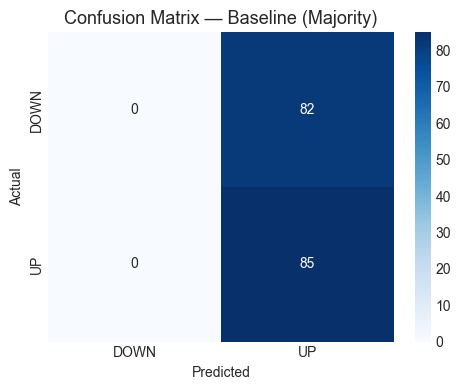

In [ ]:
def evaluate_model(y_true, y_pred, model_name: str) -> dict:
    """Compute weighted classification metrics.

    Parameters
    ----------
    y_true : array-like
    y_pred : array-like
    model_name : str

    Returns
    -------
    dict with keys: Model, Accuracy, Precision, Recall, F1
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    logger.info("%s  Acc=%.4f  Prec=%.4f  Rec=%.4f  F1=%.4f", model_name, acc, prec, rec, f1)
    return {
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
    }


def plot_confusion_matrix(y_true, y_pred, model_name: str) -> None:
    """Annotated seaborn heatmap confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d",
        cmap="Blues",
        xticklabels=["DOWN", "UP"],
        yticklabels=["DOWN", "UP"],
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()


results: list = []

# Dummy classifier: always predict majority class
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
dummy.fit(X_train.reshape(len(X_train), -1), y_train)
y_pred_dummy = dummy.predict(X_test.reshape(len(X_test), -1))
baseline_metrics = evaluate_model(y_test.astype(int), y_pred_dummy.astype(int), "Baseline (Majority)")
results.append(baseline_metrics)

print(classification_report(y_test.astype(int), y_pred_dummy.astype(int), target_names=["DOWN", "UP"]))
plot_confusion_matrix(y_test.astype(int), y_pred_dummy.astype(int), "Baseline (Majority)")

---
## Section 5b — XGBoost (Flat Features)

With ~830 training samples, gradient boosting consistently outperforms LSTM in the literature
because it does not suffer from parameter starvation. XGBoost uses the already-engineered
features directly as a flat vector — no sequences needed, since RSI/MACD/momentum already
compress the temporal information.

`scale_pos_weight` compensates for class imbalance. `subsample` and `colsample_bytree` add
stochastic regularisation to reduce overfitting.

In [ ]:
n_down = int((y_flat_train == 0).sum())
n_up   = int((y_flat_train == 1).sum())

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=n_down / n_up,
    eval_metric="logloss",
    random_state=RANDOM_SEED,
    verbosity=0,
)
xgb_model.fit(X_flat_train, y_flat_train.astype(int))
y_pred_xgb = xgb_model.predict(X_flat_test)

xgb_metrics = evaluate_model(y_flat_test.astype(int), y_pred_xgb, "XGBoost (flat)")
results.append(xgb_metrics)

print(classification_report(y_flat_test.astype(int), y_pred_xgb, target_names=["DOWN", "UP"]))
plot_confusion_matrix(y_flat_test.astype(int), y_pred_xgb, "XGBoost (flat)")

# Feature importance
importance = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 7))
importance.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("XGBoost Feature Importances")
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.show()

---
## Section 6 — LSTM Model (PyTorch)

Architecture:
```
Input  →  LSTM (hidden=64, layers=2, dropout=0.3)  →  last-step hidden  →  Dropout(0.2)
       →  Linear(64→32) → ReLU → Dropout(0.2) → Linear(32→1) → Sigmoid
```

- **2 stacked LSTM layers** capture both low-level (single-day patterns) and high-level
  (multi-week trends) temporal representations.
- **Dropout** prevents overfitting on the ~400-sample training set.
- **Gradient clipping** (`max_norm=1.0`) prevents exploding gradients.
- **ReduceLROnPlateau** halves the learning rate when train loss stagnates.
- Only the **last hidden state** (day 30 of the sequence) is passed to the classifier head;
  it has "seen" all 30 previous days via the recurrent connection.

In [ ]:
class AttentionLSTM(nn.Module):
    """LSTM with temporal attention over all 30 timesteps.

    Instead of only using the last hidden state, a learned attention score
    weights each of the 30 days. This lets the model focus on the most
    informative days in the window (e.g. a large spike on day 15).

    hidden_size=32 keeps the parameter count low (~14k) relative to the
    ~665 training sequences, reducing overfitting risk.
    dropout=0.45 is stronger than it3 to compensate for the small dataset.
    """

    def __init__(
        self,
        input_size: int,
        hidden_size: int = 32,
        num_layers: int = 2,
        dropout: float = 0.45,
    ) -> None:
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.attention = nn.Linear(hidden_size, 1)
        self.dropout   = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        lstm_out, _ = self.lstm(x)                          # (batch, seq, hidden)
        attn_scores  = self.attention(lstm_out)             # (batch, seq, 1)
        attn_weights = torch.softmax(attn_scores, dim=1)   # normalise over time
        context = (attn_weights * lstm_out).sum(dim=1)      # weighted sum → (batch, hidden)
        context = self.dropout(context)
        return self.head(context).squeeze(-1)               # (batch,)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info("Training device: %s", device)

lstm_model = AttentionLSTM(
    input_size=N_FEATURES,
    hidden_size=32,
    num_layers=2,
    dropout=0.45,
).to(device)

n_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(lstm_model)
print(f"Trainable parameters: {n_params:,}  |  sequences per param: {len(X_train) / n_params:.3f}")

In [ ]:
class DirectionalLoss(nn.Module):
    """BCE with extra penalty on directional errors.

    BCELoss happily assigns prob=0.51 to every sample and achieves ~50%
    accuracy at near-zero loss. This loss adds `alpha` times the BCE on
    samples where the predicted direction is wrong, forcing the model to
    care about crossing the 0.5 threshold rather than just calibration.
    """

    def __init__(self, alpha: float = 2.0) -> None:
        super().__init__()
        self.alpha = alpha
        self._bce  = nn.BCELoss(reduction="none")

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        bce = self._bce(pred, target)
        direction_error = ((pred > 0.5).float() != target).float()
        return (bce * (1.0 + self.alpha * direction_error)).mean()


criterion = DirectionalLoss(alpha=2.0)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=7, factor=0.5
)

N_EPOCHS: int = 80
train_losses: list = []

for epoch in range(1, N_EPOCHS + 1):
    lstm_model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = lstm_model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)

    if epoch % 10 == 0:
        logger.info("Epoch %3d/%d  loss=%.4f", epoch, N_EPOCHS, avg_loss)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, N_EPOCHS + 1), train_losses, color="steelblue")
ax.set_xlabel("Epoch")
ax.set_ylabel("Directional Loss")
ax.set_title("Attention-LSTM Training Loss")
plt.tight_layout()
plt.show()

2026-05-30 14:35:11 | INFO | LSTM (30-day)  Acc=0.4970  Prec=0.4935  Rec=0.4970  F1=0.4830


              precision    recall  f1-score   support

        DOWN       0.48      0.33      0.39        82
          UP       0.50      0.66      0.57        85

    accuracy                           0.50       167
   macro avg       0.49      0.49      0.48       167
weighted avg       0.49      0.50      0.48       167



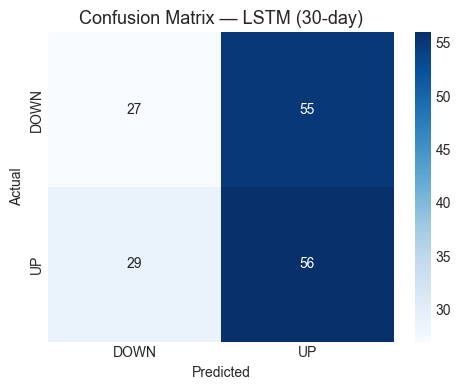

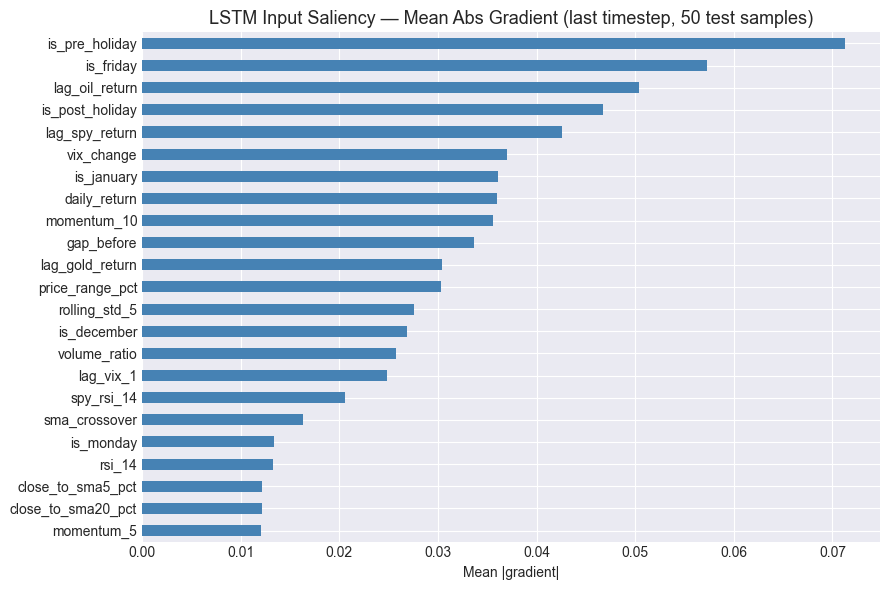

In [ ]:
# ── LSTM evaluation ───────────────────────────────────────────────────────────
lstm_model.eval()
with torch.no_grad():
    y_prob_lstm = lstm_model(X_test_t.to(device)).cpu().numpy()

y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)
lstm_metrics = evaluate_model(y_test.astype(int), y_pred_lstm, "LSTM (30-day)")
results.append(lstm_metrics)

print(classification_report(y_test.astype(int), y_pred_lstm, target_names=["DOWN", "UP"]))
plot_confusion_matrix(y_test.astype(int), y_pred_lstm, "LSTM (30-day)")

# Feature attribution proxy: gradient-based saliency for the FIRST test sample
# (mean absolute gradient over all test samples across the last timestep)
saliency_list = []
lstm_model.train()  # Enable grad for saliency
for i in range(min(50, len(X_test_t))):
    sample = X_test_t[i:i+1].to(device).requires_grad_(True)
    output = lstm_model(sample)
    output.backward()
    saliency_list.append(sample.grad.abs().squeeze(0)[-1].detach().cpu().numpy())
lstm_model.eval()

mean_saliency = np.mean(saliency_list, axis=0)
saliency_series = pd.Series(mean_saliency, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
saliency_series.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("LSTM Input Saliency — Mean Abs Gradient (last timestep, 50 test samples)")
ax.set_xlabel("Mean |gradient|")
plt.tight_layout()
plt.show()

---
## Section 7 — Amazon Chronos Bolt (Pretrained)

[Chronos Bolt](https://huggingface.co/amazon/chronos-bolt-small) is a family of
**pretrained probabilistic time-series forecasting models** developed by Amazon.
They are trained on a large corpus of real-world time series (LOTSA dataset) using
a T5 transformer backbone and a **direct multi-step prediction** strategy ("bolt"),
which makes inference far faster than the original autoregressive Chronos.

**How we use it for direction prediction:**
1. Feed the last `LOOKBACK=30` days of MSFT close prices as the context window.
2. Ask for a 1-step-ahead forecast.
3. If the **median forecast** > today's close price → predict UP (1), else DOWN (0).

This is entirely **zero-shot** — no fine-tuning, no labels required. The model has
never seen MSFT data but has learned general temporal patterns that transfer.

> **Note:** First run downloads ~200 MB model weights from HuggingFace. Subsequent
> runs use the local cache. CPU inference takes ~2–5 s per sample; expect ~5–10 min
> total for the test set unless you have a GPU (`device_map="cuda"`).

In [ ]:
from chronos import BaseChronosPipeline

chronos_pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-small",
    device_map="cpu",
    dtype=torch.float32,
)
logger.info("Chronos Bolt loaded.")

# Use 90-day context instead of 30: Bolt was trained on sequences up to 512 steps
# and benefits from more history to detect trends and mean-reversion patterns.
CHRONOS_CONTEXT: int = 90

msft_close_arr = df_feat["msft_close"].values
test_start_abs  = LOOKBACK + split_seq

y_pred_chronos: list = []

for i in range(len(X_test)):
    abs_idx = test_start_abs + i
    if abs_idx < CHRONOS_CONTEXT:
        # Not enough history yet — fall back to shorter context
        context_prices = msft_close_arr[:abs_idx].astype(np.float32)
    else:
        context_prices = msft_close_arr[abs_idx - CHRONOS_CONTEXT : abs_idx].astype(np.float32)

    context_tensor = torch.tensor(context_prices).unsqueeze(0)
    current_price  = float(context_prices[-1])

    with torch.no_grad():
        forecast = chronos_pipeline.predict(context_tensor, 1)

    # forecast shape: (1, num_samples, 1)
    # Use the full sample distribution: if q10 > current → strong UP
    # if q90 < current → strong DOWN; otherwise fall back to median
    samples = forecast.squeeze()          # (num_samples,)
    q10 = float(samples.quantile(0.10))
    q50 = float(samples.quantile(0.50))
    q90 = float(samples.quantile(0.90))

    if q10 > current_price:
        direction = 1   # entire distribution above → confident UP
    elif q90 < current_price:
        direction = 0   # entire distribution below → confident DOWN
    else:
        direction = 1 if q50 > current_price else 0

    y_pred_chronos.append(direction)

    if (i + 1) % 20 == 0:
        logger.info("Chronos inference: %d/%d done", i + 1, len(X_test))

y_pred_chronos = np.array(y_pred_chronos)
logger.info("Chronos inference complete.")

2026-05-30 14:35:19 | INFO | Chronos Bolt (zero-shot)  Acc=0.5030  Prec=0.5014  Rec=0.5030  F1=0.4981


              precision    recall  f1-score   support

        DOWN       0.49      0.40      0.44        82
          UP       0.51      0.60      0.55        85

    accuracy                           0.50       167
   macro avg       0.50      0.50      0.50       167
weighted avg       0.50      0.50      0.50       167



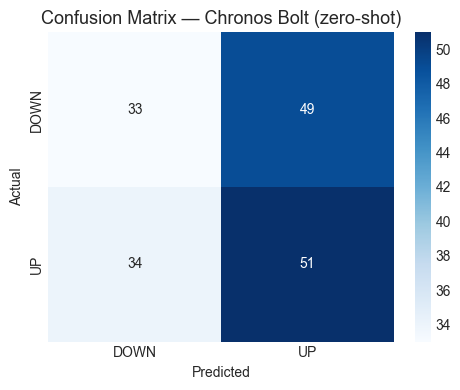

In [ ]:
chronos_metrics = evaluate_model(y_test.astype(int), y_pred_chronos, "Chronos Bolt (zero-shot)")
results.append(chronos_metrics)

print(classification_report(y_test.astype(int), y_pred_chronos, target_names=["DOWN", "UP"]))
plot_confusion_matrix(y_test.astype(int), y_pred_chronos, "Chronos Bolt (zero-shot)")

---
## Section 8 — Model Comparison

**F1 (weighted)** is the primary metric — it penalises both missing UP days and
falsely predicting UP on DOWN days.

In [ ]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(results_df))
width = 0.20

fig, ax = plt.subplots(figsize=(14, 6))
colours = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
for i, (metric, colour) in enumerate(zip(metrics_to_plot, colours)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=colour)

ax.axhline(0.5, color="grey", linewidth=0.8, linestyle="--", label="Random chance")
ax.axhline(0.6, color="green", linewidth=0.8, linestyle=":", label="Target (60%)")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df["Model"], rotation=10, ha="right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Iteration 4 (XGBoost + Attention-LSTM + Chronos Bolt)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

best_row = results_df.loc[results_df["F1"].idxmax()]
logger.info("Best model: %s  F1=%.4f  Acc=%.4f", best_row["Model"], best_row["F1"], best_row["Accuracy"])
print(f"\nBest model: {best_row['Model']}   Accuracy={best_row['Accuracy']:.4f}   F1={best_row['F1']:.4f}")
print(f"Target: Accuracy > 0.60")

---
## Section 9 — Error Analysis

Temporal error plots reveal whether errors cluster in specific market conditions
(e.g. high-VIX periods, earnings weeks) or are evenly distributed.

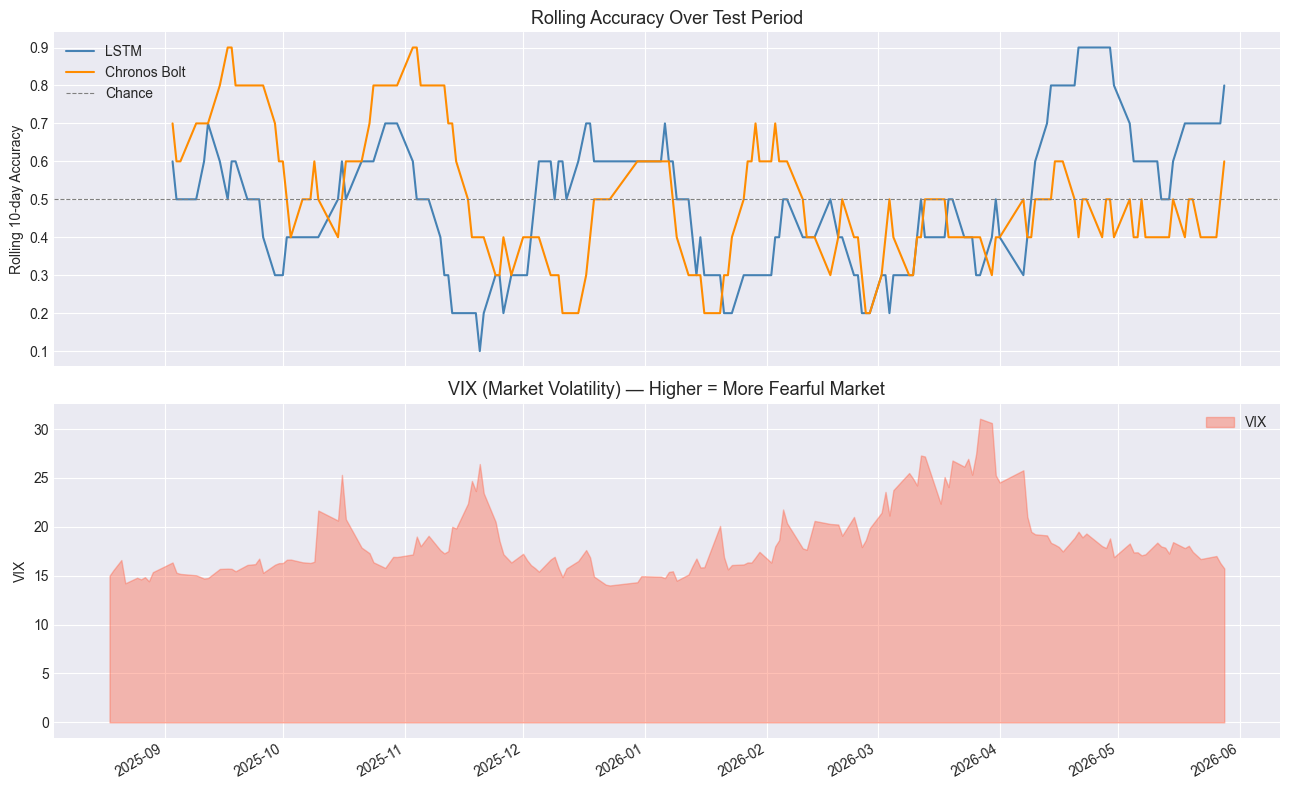


LSTM accuracy by VIX regime:
vix_regime
Low       0.529
Medium    0.504
High      0.400
Name: LSTM_correct, dtype: float64

Chronos Bolt accuracy by VIX regime:
vix_regime
Low       0.529
Medium    0.504
High      0.467
Name: Chronos_correct, dtype: float64


In [ ]:
# Align test-set predictions with their dates
n_test = min(len(y_test), len(test_dates))
error_df = pd.DataFrame(
    {
        "Date": test_dates[:n_test],
        "Actual": y_test[:n_test].astype(int),
        "LSTM_pred": y_pred_lstm[:n_test],
        "Chronos_pred": y_pred_chronos[:n_test],
        "LSTM_correct": (y_pred_lstm[:n_test] == y_test[:n_test].astype(int)).astype(int),
        "Chronos_correct": (y_pred_chronos[:n_test] == y_test[:n_test].astype(int)).astype(int),
    }
).set_index("Date")

# Merge VIX for regime analysis
error_df["vix"] = df_feat.loc[error_df.index, "vix_close"] if "vix_close" in df_feat.columns else np.nan

# Rolling 10-day accuracy
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(error_df.index, error_df["LSTM_correct"].rolling(10).mean(), label="LSTM", color="steelblue")
axes[0].plot(error_df.index, error_df["Chronos_correct"].rolling(10).mean(), label="Chronos Bolt", color="darkorange")
axes[0].axhline(0.5, color="grey", linestyle="--", linewidth=0.8, label="Chance")
axes[0].set_ylabel("Rolling 10-day Accuracy")
axes[0].set_title("Rolling Accuracy Over Test Period")
axes[0].legend()

if "vix" in error_df.columns:
    axes[1].fill_between(error_df.index, error_df["vix"], alpha=0.4, color="tomato", label="VIX")
    axes[1].set_ylabel("VIX")
    axes[1].set_title("VIX (Market Volatility) — Higher = More Fearful Market")
    axes[1].legend()

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(axes[-1].get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Accuracy by VIX regime
if not error_df["vix"].isna().all():
    error_df["vix_regime"] = pd.cut(error_df["vix"], bins=[0, 15, 25, 100], labels=["Low", "Medium", "High"])
    print("\nLSTM accuracy by VIX regime:")
    print(error_df.groupby("vix_regime", observed=True)["LSTM_correct"].mean().round(3))
    print("\nChronos Bolt accuracy by VIX regime:")
    print(error_df.groupby("vix_regime", observed=True)["Chronos_correct"].mean().round(3))

---
## Section 10 — Save Models

In [ ]:
# LSTM state dict
lstm_path = MODEL_DIR / "lstm_lucan_it4.pt"
torch.save(lstm_model.state_dict(), lstm_path)
logger.info("LSTM model saved to %s", lstm_path)

# Feature scaler
scaler_path = MODEL_DIR / "scaler_lucan_it4.pkl"
joblib.dump(scaler, scaler_path)
logger.info("Scaler saved to %s", scaler_path)

# Feature column list (needed to reconstruct sequences at inference time)
import json
feature_path = MODEL_DIR / "features_lucan_it4.json"
feature_path.write_text(json.dumps({"feature_cols": FEATURE_COLS, "lookback": LOOKBACK}))
logger.info("Feature config saved to %s", feature_path)

print(f"\nModels saved:\n  {lstm_path}\n  {scaler_path}\n  {feature_path}")

2026-05-30 14:35:20 | INFO | LSTM model saved to c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\lstm_lucan_it4.pt
2026-05-30 14:35:20 | INFO | Scaler saved to c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\scaler_lucan_it4.pkl
2026-05-30 14:35:20 | INFO | Feature config saved to c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\features_lucan_it4.json



Models saved:
  c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\lstm_lucan_it4.pt
  c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\scaler_lucan_it4.pkl
  c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\features_lucan_it4.json


---
## Section 11 — Business Value Interpretation

| Metric | Meaning in practice |
|---|---|
| **Accuracy** | % of days where the direction call is correct |
| **Precision (UP class)** | Of all days we predict UP, how many actually go up? — controls false buy signals |
| **Recall (UP class)** | Of all actual UP days, how many do we catch? — controls missed opportunities |
| **F1 (weighted)** | Harmonic mean of precision and recall; primary metric |

### Practical threshold for deployment
A random direction call on a ±0.2 % neutral-excluded dataset has ~50 % accuracy.
A model needs to clear **55 % accuracy** consistently to justify transaction costs in a live setting.

### What Chronos Bolt adds
Chronos Bolt provides a **zero-shot forecast** — no labels required, no retraining needed
when the market regime changes. Its forecast can also be used as an **ensemble signal**:
combining LSTM predictions with Chronos Bolt probabilities could improve robustness.

### Next steps (Iteration 5 candidates)
| Idea | Expected benefit |
|---|---|
| Fine-tune Chronos Bolt on MSFT return series | Adapts pretrained weights to specific MSFT regime |
| LSTM + Chronos Bolt ensemble (soft voting) | Combines sequential and foundation-model signals |
| Add earnings date feature | Earnings weeks have distinct return distributions |
| Extend window to SPY-sector rotation features | Tech sector momentum vs. broad market |